In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import warnings

warnings.filterwarnings("ignore")

# Setting up visualization style
plt.style.use("seaborn-v0_8")
sns.set_style("darkgrid")

print("All libraries imported successfully")

All libraries imported successfully


load data set

In [5]:
df = pd.read_csv("retail_sales.csv")
df.head(10)

,Date,Category,Sales,Quantity,Profit,Region
0,1/1/2023,Electronics,1149.014246,11.0,383.664245,North
1,1/1/2023,Clothing,958.520710,7.0,224.054049,East
2,1/1/2023,Home Goods,1473.763845,2.0,466.593090,South
3,1/1/2023,Sports,1230.230419,6.0,123.310460,West
4,1/1/2023,NaN?,828.585950,12.0,88.591355,East
5,1/2/2023,Electronics,722.775149,10.0,82.396149,West
6,1/2/2023,Clothing,788.996859,15.0,225.271072,West
7,1/2/2023,Home Goods,358.113803,3.0,128.198339,East
8,1/2/2023,Sports,819.923845,2.0,250.298077,East
9,1/2/2023,Books,1284.231946,7.0,363.436353,West


expalintion: this cell provide basic information about dataset include name , datatype, and check for missing value 

In [6]:
#basic data information
print("Data set basic information")
print(f"dataset dimension : {df.shape[0]} row * {df.shape[1]} columns")
print("\nData types of each column")
print(df.dtypes)

Data set basic information
dataset dimension : 1825 row * 6 columns

Data types of each column
Date            str
Category        str
Sales       float64
Quantity    float64
Profit      float64
Region          str
dtype: object


In [7]:
print("print massing value")
print(df.isnull().sum())
print("\ndataset summery")
df.info()

print massing value
Date        0
Category    4
Sales       2
Quantity    5
Profit      0
Region      5
dtype: int64

dataset summery
<class 'pandas.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1825 non-null   str    
 1   Category  1821 non-null   str    
 2   Sales     1823 non-null   float64
 3   Quantity  1820 non-null   float64
 4   Profit    1825 non-null   float64
 5   Region    1820 non-null   str    
dtypes: float64(3), str(3)
memory usage: 85.7 KB


In [11]:
# Data cleaning and conversion
print("Data cleaning and conversion")

# Clean column names
df.columns = df.columns.str.strip()

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"])

# Extract date features
df["Month"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["MonthName"] = df["Date"].dt.month_name()

# Convert numeric columns
numeric_columns = ["Sales", "Profit", "Quantity"]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Data after conversion:")
print(df.dtypes)

print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")

Data cleaning and conversion
Data after conversion:
Date         datetime64[us]
Category                str
Sales               float64
Quantity            float64
Profit              float64
Region                  str
Month                 int32
quarter               int32
dayofweek             int32
MonthName               str
Quarter               int32
DayOfWeek             int32
dtype: object
Date range: 2023-01-01 00:00:00 to 2023-12-31 00:00:00


Explnation : this cell provide comperihensive statatical sum ,dispersion, agrigation, by catagry and region

In [12]:
print("Statistical summery")
print("descriptive statistics for numerice columns")
print(df[["Sales", "Profit", "Quantity"]].describe())

Statistical summery
descriptive statistics for numerice columns
             Sales       Profit     Quantity
count  1823.000000  1825.000000  1820.000000
mean    980.482677   248.696130    10.053846
std     336.756618   118.159627     5.515370
min       0.000000     0.000000     0.000000
25%     784.071354   156.916498     5.000000
50%     997.725134   229.344557    10.000000
75%    1208.512721   324.867847    15.000000
max    1888.932537   703.228418    19.000000


In [13]:
print("category wise summery")
category_summery= df.groupby("Category").agg({
    "Sales":['count', 'sum', 'mean','std'],
    "Quantity":['sum', 'mean'],
    'Profit':['sum', 'mean']
    
}).round(2)
print(category_summery)

category wise summery
            Sales                             Quantity           Profit  \
            count        sum     mean     std      sum   mean       sum   
Category                                                                  
Books         364  370971.87  1019.15  336.39   3737.0  10.27  92304.45   
Clothing      365  350981.82   961.59  337.49   3641.0   9.98  90082.12   
Electronics   360  364090.41  1011.36  344.25   3595.0   9.96  90439.70   
Home Goods    364  347493.83   954.65  332.39   3777.0  10.38  87447.82   
NaN?            1     828.59   828.59     NaN     12.0  12.00     88.59   
Nan             1     823.19   823.19     NaN      4.0   4.00    253.43   
Null            1    1106.85  1106.85     NaN     11.0  11.00    381.78   
Sports        363  346685.06   955.06  331.20   3492.0   9.73  92065.22   

                     
               mean  
Category             
Books        253.58  
Clothing     246.80  
Electronics  250.53  
Home Goods   240.24 

In [14]:
print("region wise summery")
Region_summery=df.groupby('Region').agg({
    "Quantity":['sum', 'mean'],
    'Profit':['sum', 'mean']
    
}).round(2)
print(Region_summery)

region wise summery
       Quantity            Profit        
            sum   mean        sum    mean
Region                                   
East     4103.0  10.36   98973.62  248.68
Nan         8.0   8.00     545.62  545.62
North    4689.0  10.22  112126.47  243.75
South    4791.0   9.90  118036.97  243.88
West     4668.0   9.81  122517.78  256.85


Expalnation: This cell analyze monthly sale trend by agregating data by month and line chart showing slae and profit pattren througe the year

In [16]:
print("Monthly sales trend analysis")

monthly_sales = df.groupby(['Month', 'MonthName']).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).reset_index()

# Sort by Month
monthly_sales = monthly_sales.sort_values("Month")

print("Monthly sales summary")
print(monthly_sales)

Monthly sales trend analysis
Monthly sales summary
    Month  MonthName          Sales        Profit  Quantity
0       1    January  147068.619477  39711.436221    1486.0
1       2   February  132215.411776  34353.123612    1517.0
2       3      March  145321.200626  38584.599285    1447.0
3       4      April  138160.991209  37895.203187    1446.0
4       5        May  150774.977103  40527.689566    1603.0
5       6       June  152605.749860  39042.686605    1570.0
6       7       July  162111.115687  40208.956109    1536.0
7       8     August  148020.452251  34675.627875    1489.0
8       9  September  153094.700793  37796.761379    1598.0
9      10    October  151272.280840  36019.384158    1569.0
10     11   November  146795.613628  36344.048332    1461.0
11     12   December  159978.807192  38710.920857    1576.0


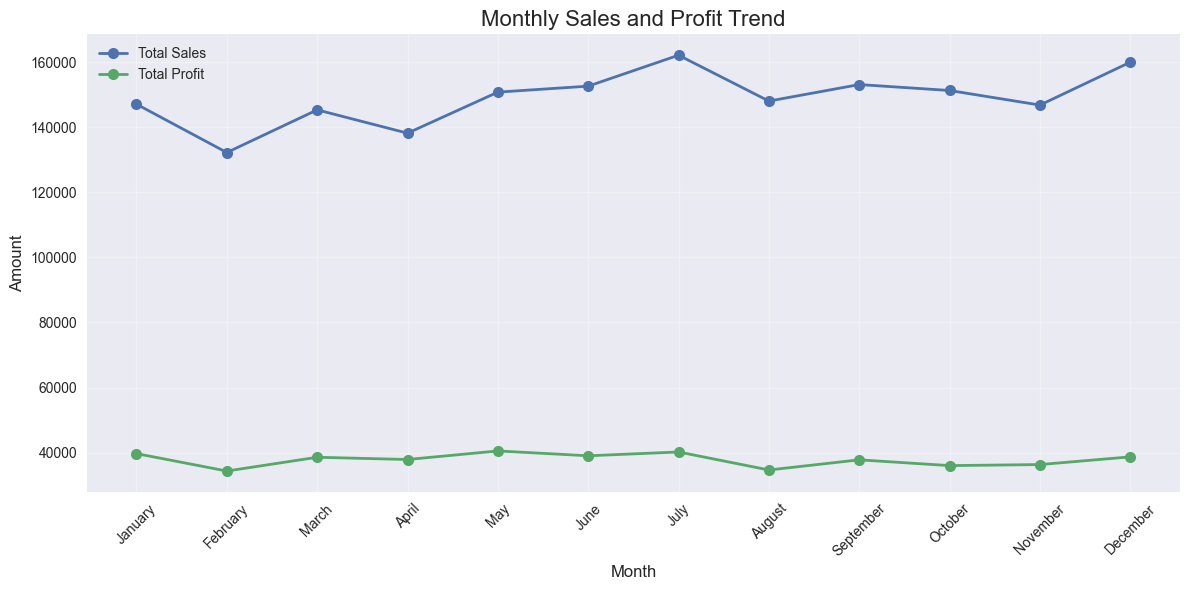

In [19]:
# Visualization: Monthly Sales Trend
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales['MonthName'],
    monthly_sales['Sales'],
    marker='o',
    linewidth=2,
    markersize=8,
    label='Total Sales'
)

plt.plot(
    monthly_sales['MonthName'],
    monthly_sales['Profit'],
    marker='o',
    linewidth=2,
    markersize=8,
    label='Total Profit'
)

plt.title("Monthly Sales and Profit Trend", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Amount", fontsize=12)

plt.legend()
plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [20]:
print("Category performance analysis")

category_performance= df.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).sort_values('Sales', ascending=False)

# Sort by Month


print("category performance")
print(category_performance)

Category performance analysis
category performance
                     Sales        Profit  Quantity
Category                                          
Books        370971.872558  92304.452141    3737.0
Electronics  364090.406288  90439.697795    3595.0
Clothing     350981.822773  90082.119920    3641.0
Home Goods   347493.827088  87447.820056    3777.0
Sports       346685.063298  92065.220851    3492.0
Null           1106.847949    381.784578      11.0
NaN?            828.585950     88.591355      12.0
Nan             823.190573    253.433301       4.0


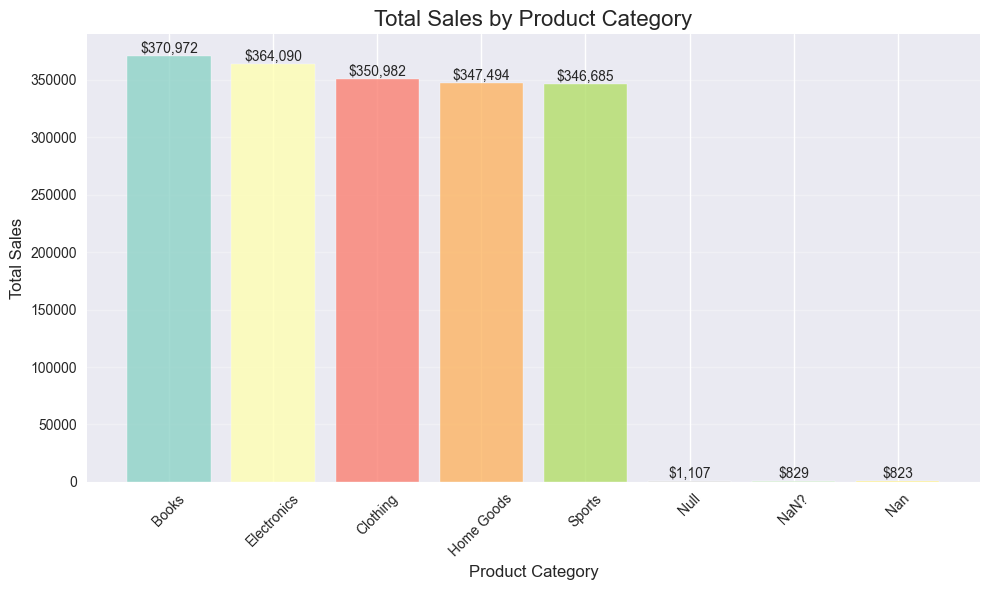

In [21]:
# Visualization
plt.figure(figsize=(10,6))

colors = plt.cm.Set3(np.linspace(0, 1, len(category_performance)))

bars = plt.bar(
    category_performance.index,
    category_performance['Sales'],
    color=colors,
    alpha=0.8
)

# Add labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'${height:,.0f}',
        ha='center',
        va='bottom'
    )

plt.title("Total Sales by Product Category", fontsize=16)
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)

plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Expalination: This cell analysis slaes perdoemaance across diffenrect region and create pie to showing the distribution of sale by region

In [23]:
print("Region performance analysis")

Region_performance = df.groupby('Region').agg({
    'Sales': ['sum', 'mean', 'count'],
    'Profit': ['sum', 'mean']
}).round(2)

# Sort by Region (not Month)
Region_performance = Region_performance.sort_index()

print("Region performance")
print(Region_performance)

Region performance analysis
Region performance
            Sales                    Profit        
              sum     mean count        sum    mean
Region                                             
East    393441.61   991.04   397   98973.62  248.68
Nan       1716.71  1716.71     1     545.62  545.62
North   448295.03   976.68   459  112126.47  243.75
South   469471.28   969.98   484  118036.97  243.88
West    470514.37   986.40   477  122517.78  256.85


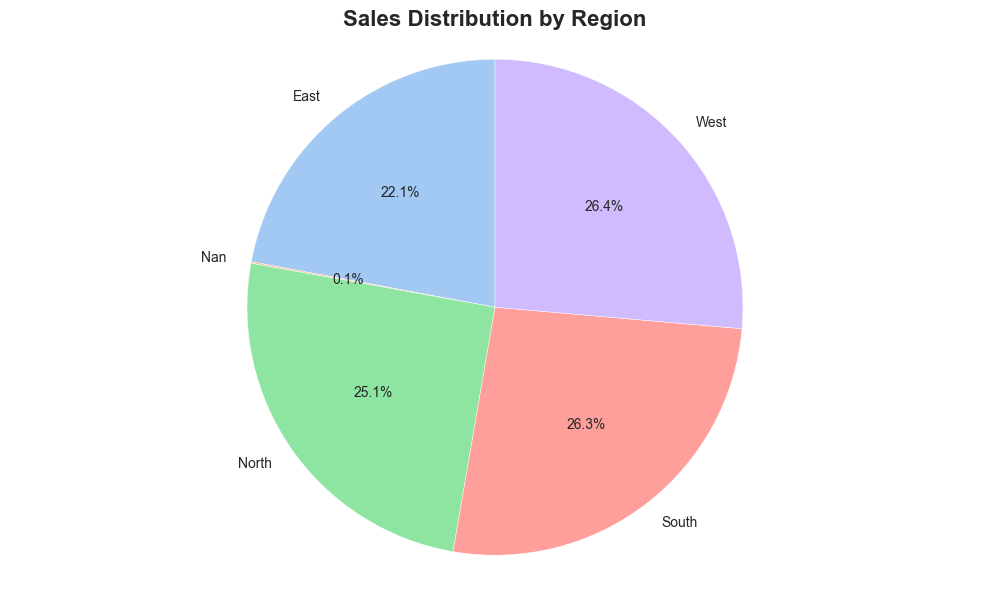

In [24]:
# Visualization: Regional Sales Distribution
plt.figure(figsize=(10,6))

regional_data = df.groupby('Region')['Sales'].sum()

plt.pie(
    regional_data,
    labels=regional_data.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('pastel')
)

plt.title("Sales Distribution by Region", fontsize=16, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

Expalination : This cell analysis the sale pattens day of week and create line chart how sale and rofit very thoughout for week.

Day of Week Analysis
Average Daily Performance
Empty DataFrame
Columns: [Sales, Profit, Quantity]
Index: []


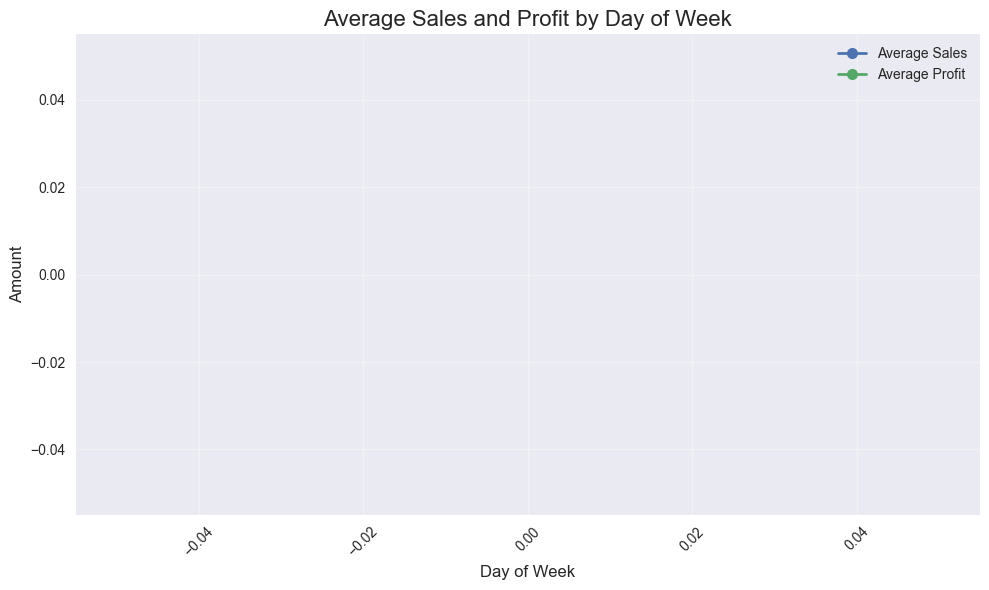

In [27]:
print("Day of Week Analysis")

# Correct order of days
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

# Convert to categorical with proper order
df['DayOfWeek'] = pd.Categorical(
    df['DayOfWeek'],
    categories=day_order,
    ordered=True
)

# Daily performance analysis
daily_performance = df.groupby('DayOfWeek').agg({
    'Sales': 'mean',
    'Profit': 'mean',
    'Quantity': 'mean'
}).round(2)

print("Average Daily Performance")
print(daily_performance)

# Visualization: Day of Week Performance
plt.figure(figsize=(10,6))

plt.plot(
    daily_performance.index,
    daily_performance['Sales'],
    marker='o',
    linewidth=2,
    markersize=8,
    label='Average Sales'
)

plt.plot(
    daily_performance.index,
    daily_performance['Profit'],
    marker='o',
    linewidth=2,
    markersize=8,
    label='Average Profit'
)

plt.title("Average Sales and Profit by Day of Week", fontsize=16)
plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Amount", fontsize=12)

plt.legend()
plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

This cell calculate the correltation between numercal variable and create visulaze relatin between 
sale queantity profit and time

Correlation Analysis
Correlation Matrix
            Profit  Quantity     Sales     Month
Profit    1.000000  0.027875  0.525041 -0.034678
Quantity  0.027875  1.000000  0.056824  0.003127
Sales     0.525041  0.056824  1.000000  0.065291
Month    -0.034678  0.003127  0.065291  1.000000


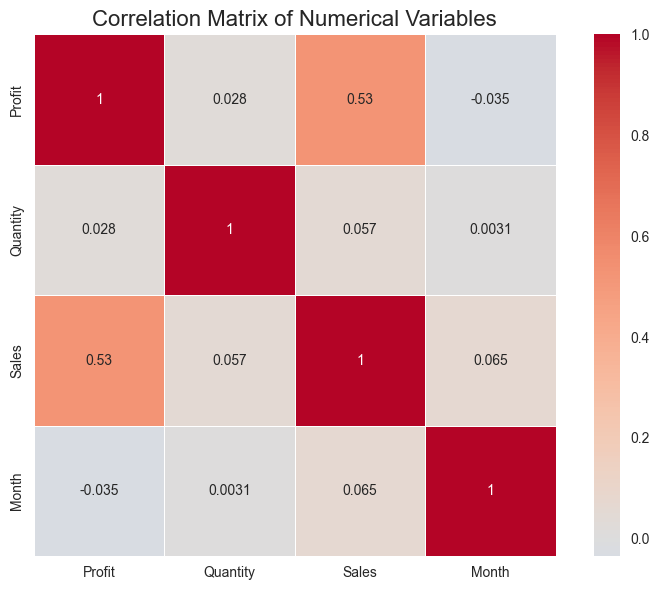

In [28]:
print("Correlation Analysis")

# Select numerical columns
numerical_df = df[['Profit', 'Quantity', 'Sales', 'Month']]

# Calculate correlation matrix
correlation_matrix = numerical_df.corr()

print("Correlation Matrix")
print(correlation_matrix)

# Visualization
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables", fontsize=16)

plt.tight_layout()
plt.show()

In [ ]:

# CHECK COLUMNS

print(df.columns)

# USE YOUR ACTUAL DATE COLUMN NAME

# Example:
# Replace 'Date' with your real date column name

df['Date'] = pd.to_datetime(df['Date'])

# Create day of week
df['DayOfWeek'] = df['Date'].dt.day_name()

# DAILY PERFORMANCE

daily_performance = df.groupby('DayOfWeek').agg({
    'Sales': 'mean',
    'Profit': 'mean',
    'Quantity': 'mean'
}).round(2)

# Arrange days properly
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

daily_performance = daily_performance.reindex(day_order)

print(daily_performance)
# KEY INSIGHTS


print("\nKey Insight Recommendations")

# Top category
top_category = category_performance['Sales'].idxmax()
print("1. Top Performing Category:", top_category)

# Best region
best_region = regional_data.idxmax()
print("2. Best Performing Region:", best_region)

# Highest sales month
highest_sales_month = monthly_sales.loc[
    monthly_sales['Sales'].idxmax(),
    'MonthName'
]

print("3. Highest Sales Month:", highest_sales_month)

# Best day
best_day = daily_performance['Sales'].idxmax()

print("4. Best Day of Week:", best_day)

# Total sales & profit
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

print(f"5. Total Annual Sales: ${total_sales:,.2f}")
print(f"6. Total Annual Profit: ${total_profit:,.2f}")

# BUSINESS RECOMMENDATIONS


print("\nBusiness Recommendations")

print(f"• Focus marketing efforts on {top_category} category")

print("• Investigate performance in lower-performing regions")

print(f"• Plan promotions around {best_day} to maximize sales")

print("• Allocate inventory based on monthly trend patterns")

print("• Monitor correlation between quantity, profit, and pricing strategy")

# PROFITABILITY ANALYSIS

print("\nProfitability Analysis")

profit_margin = (total_profit / total_sales) * 100

print(f"Overall Profit Margin: {profit_margin:.2f}%")

# Category-wise profit margin
category_margin = (
    category_performance['Profit'] /
    category_performance['Sales']
) * 100

print("\nProfit Margin by Category:")

for category, margin in category_margin.items():
    print(f"{category}: {margin:.2f}%")

Index(['Date', 'Category', 'Sales', 'Quantity', 'Profit', 'Region', 'Month',
       'quarter', 'dayofweek', 'MonthName', 'Quarter', 'DayOfWeek'],
      dtype='str')
             Sales  Profit  Quantity
DayOfWeek                           
Monday      981.77  253.32     10.24
Tuesday     981.92  244.18     10.31
Wednesday   965.23  237.57     10.18
Thursday    966.83  237.62      9.78
Friday     1014.31  259.80     10.00
Saturday    972.20  253.32      9.64
Sunday      981.11  254.94     10.22

Key Insight Recommendations
1. Top Performing Category: Books
2. Best Performing Region: West
3. Highest Sales Month: July
4. Best Day of Week: Friday
5. Total Annual Sales: $1,787,419.92
6. Total Annual Profit: $453,870.44

Business Recommendations
• Focus marketing efforts on Books category
• Investigate performance in lower-performing regions
• Plan promotions around Friday to maximize sales
• Allocate inventory based on monthly trend patterns
• Monitor correlation between quantity, profit, an